In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

In [4]:
import os

print("Current Directory:")
print(os.getcwd())

print("\nFiles and Folders:")
print(os.listdir())

Current Directory:
c:\Users\KiTE\Desktop\LearnPulse-AI\week 2

Files and Folders:
['.venv', 'LearnPulse_Preprocessing.ipynb', 'Students_dataset']


In [6]:
student_info = pd.read_csv("Students_dataset/studentInfo.csv")

student_vle = pd.read_csv("Students_dataset/studentVle.csv")

student_assessment = pd.read_csv(
    "Students_dataset/studentAssessment.csv"
)

student_registration = pd.read_csv(
    "Students_dataset/studentRegistration.csv"
)

print("Datasets Loaded Successfully!")

Datasets Loaded Successfully!


In [7]:
print("Student Info Shape:", student_info.shape)

print("Student VLE Shape:", student_vle.shape)

print("Student Assessment Shape:",student_assessment.shape)

print("Student Registration Shape:",student_registration.shape)

Student Info Shape: (32593, 12)
Student VLE Shape: (10655280, 6)
Student Assessment Shape: (173912, 5)
Student Registration Shape: (32593, 5)


In [9]:
print("Student Info Columns:")
print(student_info.columns.tolist())

print("\nStudent VLE Columns:")
print(student_vle.columns.tolist())

print("\nStudent Assessment Columns:")
print(student_assessment.columns.tolist())

print("\nStudent Registration Columns:")
print(student_registration.columns.tolist())

Student Info Columns:
['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']

Student VLE Columns:
['code_module', 'code_presentation', 'id_student', 'id_site', 'date', 'sum_click']

Student Assessment Columns:
['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score']

Student Registration Columns:
['code_module', 'code_presentation', 'id_student', 'date_registration', 'date_unregistration']


In [8]:
print("===== STUDENT INFO =====")
display(student_info.head())

print("===== STUDENT ASSESSMENT =====")
display(student_assessment.head())

print("===== STUDENT REGISTRATION =====")
display(student_registration.head())

print("===== STUDENT VLE =====")
display(student_vle.head())

===== STUDENT INFO =====


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


===== STUDENT ASSESSMENT =====


,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0


===== STUDENT REGISTRATION =====


,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0
3,AAA,2013J,31604,-52.0,NaN
4,AAA,2013J,32885,-176.0,NaN


===== STUDENT VLE =====


,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


In [10]:
student_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   code_module           32593 non-null  object
 1   code_presentation     32593 non-null  object
 2   id_student            32593 non-null  int64 
 3   gender                32593 non-null  object
 4   region                32593 non-null  object
 5   highest_education     32593 non-null  object
 6   imd_band              31482 non-null  object
 7   age_band              32593 non-null  object
 8   num_of_prev_attempts  32593 non-null  int64 
 9   studied_credits       32593 non-null  int64 
 10  disability            32593 non-null  object
 11  final_result          32593 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.0+ MB


In [11]:
print("===== MISSING VALUES =====")

missing_values = student_info.isnull().sum()

print(missing_values)

print("\nTotal Missing Values:")
print(missing_values.sum())

===== MISSING VALUES =====
code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                1111
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
dtype: int64

Total Missing Values:
1111


In [12]:
print("===== FINAL RESULT DISTRIBUTION =====")

print(
    student_info["final_result"]
    .value_counts()
)

===== FINAL RESULT DISTRIBUTION =====
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64


In [ ]:
print("===== EDUCATION LEVELS =====")

print(student_info["highest_education"].value_counts())

===== EDUCATION LEVELS =====
highest_education
A Level or Equivalent          14045
Lower Than A Level             13158
HE Qualification                4730
No Formal quals                  347
Post Graduate Qualification      313
Name: count, dtype: int64


In [ ]:
print("===== AGE GROUPS =====")

print(student_info["age_band"].value_counts())

===== AGE GROUPS =====
age_band
0-35     22944
35-55     9433
55<=       216
Name: count, dtype: int64


In [15]:
print("===== DISABILITY STATUS =====")

print(student_info["disability"].value_counts())

===== DISABILITY STATUS =====
disability
N    29429
Y     3164
Name: count, dtype: int64


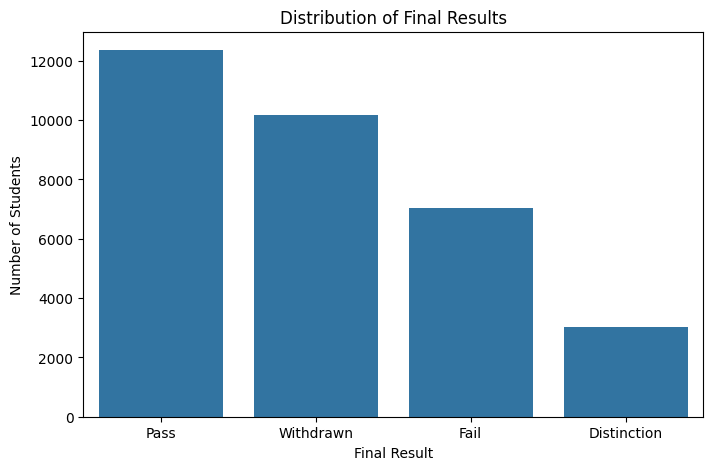

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="final_result",
    data=student_info
)

plt.title("Distribution of Final Results")

plt.xlabel("Final Result")

plt.ylabel("Number of Students")

plt.show()

In [18]:
student_info["imd_band"] = (student_info["imd_band"].fillna("Unknown"))

print("Missing Values After Cleaning:")

print(student_info.isnull().sum())

Missing Values After Cleaning:
code_module             0
code_presentation       0
id_student              0
gender                  0
region                  0
highest_education       0
imd_band                0
age_band                0
num_of_prev_attempts    0
studied_credits         0
disability              0
final_result            0
dtype: int64


In [ ]:
assessment_features = (
    student_assessment
    .groupby("id_student")
    .agg(
        average_score=("score", "mean"),
        assessment_count=("score", "count")
    )
    .reset_index()
)

assessment_features.head()

,id_student,average_score,assessment_count
0,6516,61.800000,5
1,8462,87.000000,7
2,11391,82.000000,5
3,23629,82.500000,4
4,23698,74.444444,9


In [ ]:
engagement_features = (
    student_vle
    .groupby("id_student")
    .agg(
        total_clicks=("sum_click", "sum"),
        avg_clicks=("sum_click", "mean")
    )
    .reset_index()
)

engagement_features.head()

,id_student,total_clicks,avg_clicks
0,6516,2791,4.216012
1,8462,656,2.157895
2,11391,934,4.765306
3,23629,161,2.728814
4,23698,910,2.983607


In [27]:
final_dataset = (
    student_info
    .merge(
        assessment_features,
        on="id_student",
        how="left"
    )
    .merge(
        engagement_features,
        on="id_student",
        how="left"
    )
)

final_dataset.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,average_score,assessment_count,total_clicks,avg_clicks
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,82.0,5.0,934.0,4.765306
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,66.4,5.0,1435.0,3.337209
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,NaN,NaN,281.0,3.697368
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,76.0,5.0,2158.0,3.254902
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,54.4,5.0,1034.0,2.937500


In [28]:
final_dataset["average_score"] = (
    final_dataset["average_score"]
    .fillna(0)
)

final_dataset["assessment_count"] = (
    final_dataset["assessment_count"]
    .fillna(0)
)

final_dataset["total_clicks"] = (
    final_dataset["total_clicks"]
    .fillna(0)
)

final_dataset["avg_clicks"] = (
    final_dataset["avg_clicks"]
    .fillna(0)
)

print(final_dataset.isnull().sum())

code_module             0
code_presentation       0
id_student              0
gender                  0
region                  0
highest_education       0
imd_band                0
age_band                0
num_of_prev_attempts    0
studied_credits         0
disability              0
final_result            0
average_score           0
assessment_count        0
total_clicks            0
avg_clicks              0
dtype: int64


In [29]:
print(final_dataset.shape)

print(final_dataset.isnull().sum())

(32593, 16)
code_module             0
code_presentation       0
id_student              0
gender                  0
region                  0
highest_education       0
imd_band                0
age_band                0
num_of_prev_attempts    0
studied_credits         0
disability              0
final_result            0
average_score           0
assessment_count        0
total_clicks            0
avg_clicks              0
dtype: int64


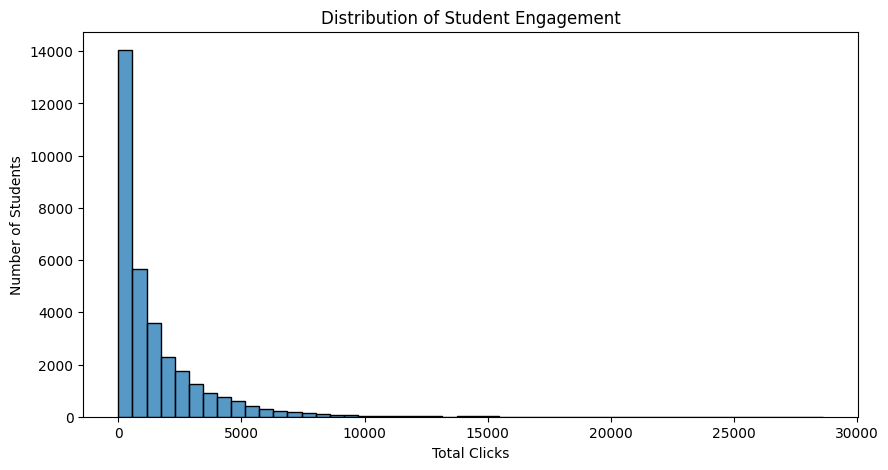

In [30]:
plt.figure(figsize=(10,5))

sns.histplot(
    final_dataset["total_clicks"],
    bins=50
)

plt.title("Distribution of Student Engagement")

plt.xlabel("Total Clicks")

plt.ylabel("Number of Students")

plt.show()

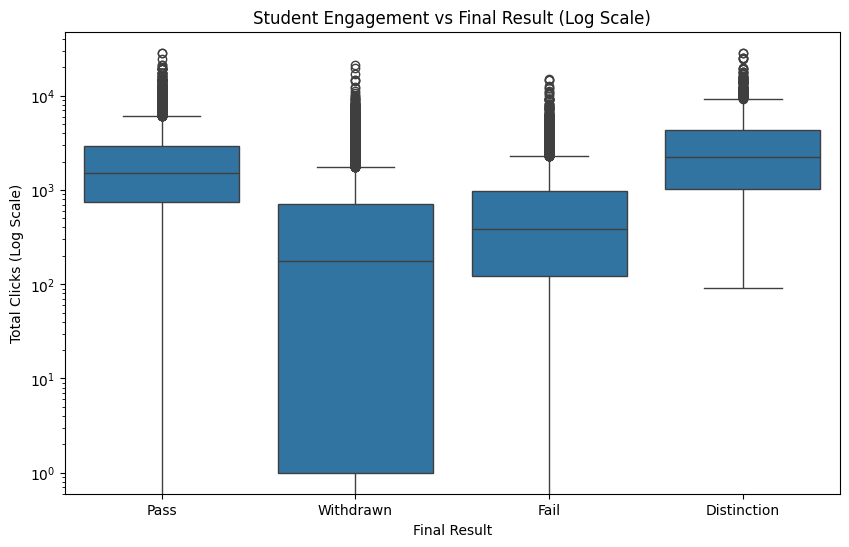

In [34]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="final_result",
    y="total_clicks",
    data=final_dataset
)

plt.yscale("log")

plt.title("Student Engagement vs Final Result (Log Scale)")
plt.xlabel("Final Result")
plt.ylabel("Total Clicks (Log Scale)")

plt.show()

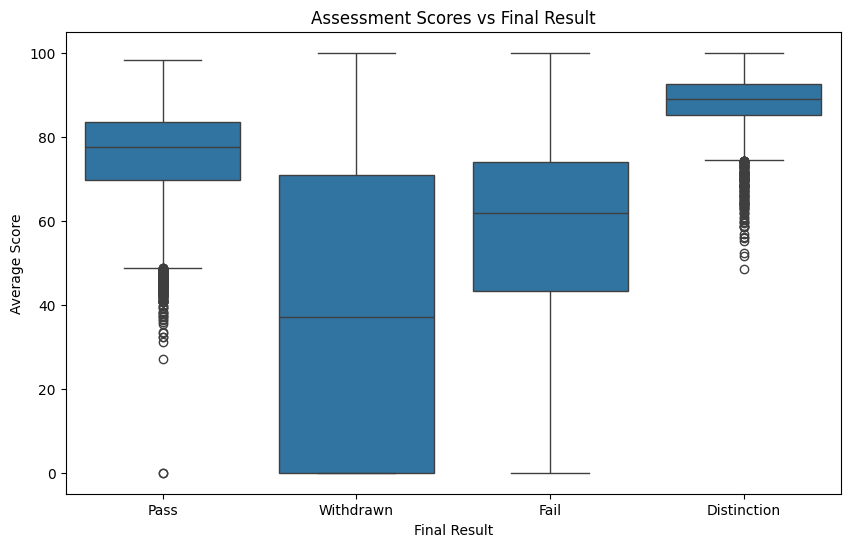

In [32]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="final_result",
    y="average_score",
    data=final_dataset
)

plt.title("Assessment Scores vs Final Result")

plt.xlabel("Final Result")

plt.ylabel("Average Score")

plt.show()

In [35]:
final_dataset.describe()

,id_student,num_of_prev_attempts,studied_credits,average_score,assessment_count,total_clicks,avg_clicks
count,3.259300e+04,32593.000000,32593.000000,32593.000000,32593.000000,32593.000000,32593.000000
mean,7.066877e+05,0.163225,79.758691,59.720644,6.353880,1479.033412,3.007920
std,5.491673e+05,0.479758,41.071900,31.328306,5.075559,2011.390856,1.467533
min,3.733000e+03,0.000000,30.000000,0.000000,0.000000,0.000000,0.000000
25%,5.085730e+05,0.000000,60.000000,50.285714,2.000000,205.000000,2.228070
50%,5.903100e+05,0.000000,60.000000,71.285714,6.000000,758.000000,2.976744
75%,6.444530e+05,0.000000,120.000000,82.222222,11.000000,1990.000000,3.922353
max,2.716795e+06,6.000000,655.000000,100.000000,28.000000,28615.000000,19.427536


In [ ]:
encoded_dataset = final_dataset.copy()

In [39]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = [
    "gender",
    "region",
    "highest_education",
    "imd_band",
    "age_band",
    "disability",
    "final_result",
    "code_module",
    "code_presentation"
]

for col in categorical_columns:
    encoded_dataset[col] = le.fit_transform(
        encoded_dataset[col]
    )

encoded_dataset.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,average_score,assessment_count,total_clicks,avg_clicks
0,0,1,11391,1,0,1,9,2,0,240,0,2,82.0,5.0,934.0,4.765306
1,0,1,28400,0,6,1,2,1,0,60,0,2,66.4,5.0,1435.0,3.337209
2,0,1,30268,0,5,0,3,1,0,60,1,3,0.0,0.0,281.0,3.697368
3,0,1,31604,0,7,0,5,1,0,60,0,2,76.0,5.0,2158.0,3.254902
4,0,1,32885,0,11,2,5,0,0,60,0,2,54.4,5.0,1034.0,2.937500


In [40]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

numerical_columns = [
    "num_of_prev_attempts",
    "studied_credits",
    "average_score",
    "assessment_count",
    "total_clicks",
    "avg_clicks"
]

encoded_dataset[numerical_columns] = scaler.fit_transform(
    encoded_dataset[numerical_columns]
)

encoded_dataset.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,average_score,assessment_count,total_clicks,avg_clicks
0,0,1,11391,1,0,1,9,2,0.0,0.336,0,2,0.820,0.178571,0.032640,0.245286
1,0,1,28400,0,6,1,2,1,0.0,0.048,0,2,0.664,0.178571,0.050149,0.171777
2,0,1,30268,0,5,0,3,1,0.0,0.048,1,3,0.000,0.000000,0.009820,0.190316
3,0,1,31604,0,7,0,5,1,0.0,0.048,0,2,0.760,0.178571,0.075415,0.167541
4,0,1,32885,0,11,2,5,0,0.0,0.048,0,2,0.544,0.178571,0.036135,0.151203


In [41]:
encoded_dataset[numerical_columns].describe()

,num_of_prev_attempts,studied_credits,average_score,assessment_count,total_clicks,avg_clicks
count,32593.000000,32593.000000,32593.000000,32593.000000,32593.000000,32593.000000
mean,0.027204,0.079614,0.597206,0.226924,0.051687,0.154828
std,0.079960,0.065715,0.313283,0.181270,0.070291,0.075539
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.048000,0.502857,0.071429,0.007164,0.114686
50%,0.000000,0.048000,0.712857,0.214286,0.026490,0.153223
75%,0.000000,0.144000,0.822222,0.392857,0.069544,0.201897
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [42]:
encoded_dataset.to_csv(
    "processed_student_dataset.csv",
    index=False
)

print("Dataset Saved Successfully!")

Dataset Saved Successfully!
